In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation

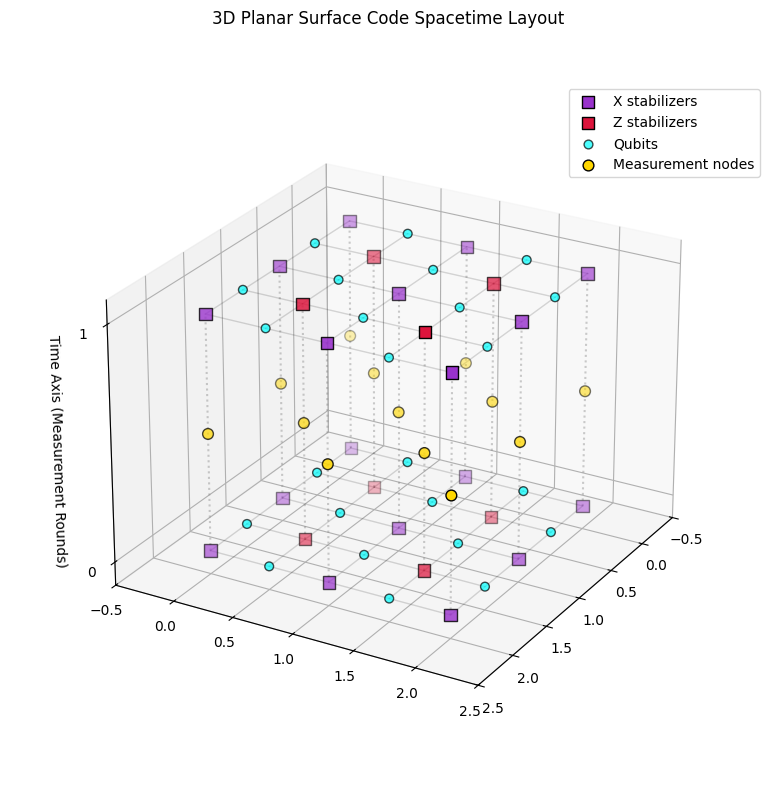

In [2]:
def build_midpoint_3d_surface(d, T):
    """
    makes the surface code diagram in the xz plane - so that time is up and down
    """
    star_stabs, plaq_stabs, qubits = [], [], []
    measurements = []
    spatial_edges = []

    for t in range(T):
        #x stab nodes
        for x in range(d):
            for y in range(d):
                star_stabs.append((x, y, t))
                
                if t < T - 1:
                    measurements.append((x, y, t + 0.5))

        #qubit connections
        for x in range(d - 1):
            for y in range(d):
                qubits.append((x + 0.5, y, t))
                spatial_edges.append(((x, y, t), (x + 0.5, y, t)))
                spatial_edges.append(((x + 0.5, y, t), (x + 1, y, t)))
        for x in range(d):
            for y in range(d - 1):
                qubits.append((x, y + 0.5, t))
                spatial_edges.append(((x, y, t), (x, y + 0.5, t)))
                spatial_edges.append(((x, y + 0.5, t), (x, y + 1, t)))

        # z stab and qubit connections
        for x in range(d - 1):
            for y in range(d - 1):
                plaq_center = (x + 0.5, y + 0.5, t)
                plaq_stabs.append(plaq_center)
                if t < T - 1:
                    measurements.append((x + 0.5, y + 0.5, t + 0.5))
                spatial_edges.append((plaq_center, (x + 0.5, y, t)))          
                spatial_edges.append((plaq_center, (x, y + 0.5, t)))          
                spatial_edges.append((plaq_center, (x + 0.5, y + 1, t)))      
                spatial_edges.append((plaq_center, (x + 1, y + 0.5, t)))     

    return star_stabs, plaq_stabs, qubits, measurements, spatial_edges

def visualize_midpoint_3d_surface(d, T):
    fig = plt.figure(figsize=(10, 8), layout='constrained')
    ax = fig.add_subplot(111, projection='3d')
    
    stars, plaqs, qubits, measurements, edges = build_midpoint_3d_surface(d, T)

    #surface code connections
    for p1, p2 in edges:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color='black', alpha=0.15, lw=1)

    #time lines
    base_nodes = set([(p[0], p[1]) for p in stars + plaqs])
    for x, y in base_nodes:
        ax.plot([x, x], [y, y], [0, T-1], color='gray', linestyle=':', alpha=0.4, zorder=1)

    # stabilisers
    xs, ys, zs = zip(*stars)
    ax.scatter(xs, ys, zs, c='darkorchid', marker='s', s=80, edgecolors='black', label='X stabilizers ', zorder=5)
    
    xs, ys, zs = zip(*plaqs)
    ax.scatter(xs, ys, zs, c='crimson', marker='s', s=80, edgecolors='black', label='Z stabilizers ', zorder=5)
    
    # qubit nodes
    xs, ys, zs = zip(*qubits)
    ax.scatter(xs, ys, zs, c='cyan', marker='o', s=40, alpha=0.7, edgecolors='black', label='Qubits', zorder=4)

    # meas nodes at midpoint of rounds
    if measurements:
        xs, ys, zs = zip(*measurements)
        ax.scatter(xs, ys, zs, c='gold', marker='o', s=60, edgecolors='black', label='Measurement nodes', zorder=6)

    ax.set_zlabel('Time Axis (Measurement Rounds)', labelpad=5)
    ax.set_box_aspect(aspect=None, zoom=0.85)

    ax.set_title('3D Planar Surface Code Spacetime Layout', pad=15)
    ax.set_xlim(-0.5, d - 0.5)
    ax.set_ylim(-0.5, d - 0.5)
    ax.set_zlim(-0.1, T - 0.9)
    ax.set_zticks(range(T))

    ax.legend(loc='upper right', bbox_to_anchor=(1, 0.95))
    ax.view_init(elev=25, azim=30)
    
    plt.show()

visualize_midpoint_3d_surface(d=3, T=2) #can change for diff distances and measurement rounds

In [ ]:
def build_adaptive_gkp_surface(d, sigma=0.1, max_allowed_rounds=10):
    """Generates surface code layers dynamically based on GKP noise threshold."""
    star_stabs, plaq_stabs, qubits = [], [], []
    trusted_measurements, failed_measurements, spatial_edges = [], [], []
    GKP_THRESHOLD = np.sqrt(np.pi) / 2.0
    t = 0
    keep_going = True
    
    while keep_going and t < max_allowed_rounds:
        # Layer t structural nodes
        for x in range(d):
            for y in range(d):
                star_stabs.append((x, y, t))
        for x in range(d - 1):
            for y in range(d):
                qubits.append((x + 0.5, y, t))
                spatial_edges.append(((x, y, t), (x + 0.5, y, t)))
                spatial_edges.append(((x + 0.5, y, t), (x + 1, y, t)))
        for x in range(d):
            for y in range(d - 1):
                qubits.append((x, y + 0.5, t))
                spatial_edges.append(((x, y, t), (x, y + 0.5, t)))
                spatial_edges.append(((x, y + 0.5, t), (x, y + 1, t)))
        for x in range(d - 1):
            for y in range(d - 1):
                plaq_center = (x + 0.5, y + 0.5, t)
                plaq_stabs.append(plaq_center)
                spatial_edges.append((plaq_center, (x + 0.5, y, t)))
                spatial_edges.append((plaq_center, (x, y + 0.5, t)))
                spatial_edges.append((plaq_center, (x + 0.5, y + 1, t)))
                spatial_edges.append((plaq_center, (x + 1, y + 0.5, t)))

        # Midpoint measurements (t + 0.5)
        any_errors_this_round = False
        for x in range(d):
            for y in range(d):
                noise = np.random.normal(0, sigma)
                if abs(noise) > GKP_THRESHOLD:
                    failed_measurements.append((x, y, t + 0.5))
                    any_errors_this_round = True
                else:
                    trusted_measurements.append((x, y, t + 0.5))
                    
        for x in range(d - 1):
            for y in range(d - 1):
                noise = np.random.normal(0, sigma)
                if abs(noise) > GKP_THRESHOLD:
                    failed_measurements.append((x + 0.5, y + 0.5, t + 0.5))
                    any_errors_this_round = True
                else:
                    trusted_measurements.append((x + 0.5, y + 0.5, t + 0.5))
        
        if any_errors_this_round:
            t += 1
        else:
            t += 1
            # Build clean terminating boundary layer
            for x in range(d):
                for y in range(d): star_stabs.append((x, y, t))
            for x in range(d - 1):
                for y in range(d): qubits.append((x + 0.5, y, t))
            for x in range(d):
                for y in range(d - 1): qubits.append((x, y + 0.5, t))
            for x in range(d - 1):
                for y in range(d - 1): plaq_stabs.append((x + 0.5, y + 0.5, t))
            keep_going = False
            
    return star_stabs, plaq_stabs, qubits, trusted_measurements, failed_measurements, spatial_edges, t + 1

def animate_adaptive_surface(d, sigma=0.4):
    stars, plaqs, qubits, trusted, failed, edges, T = build_adaptive_gkp_surface(d, sigma)
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    num_frames = T * 2 - 1 

    def update(frame):
        # 1. Clear the old axes entirely to force a hard 3D render refresh
        ax.cla()
        
        current_z = frame / 2.0
        
        # 2. Re-establish layout parameters
        ax.set_xlim(-0.5, d - 0.5)
        ax.set_ylim(-0.5, d - 0.5)
        ax.set_zlim(-0.1, T - 0.9)
        ax.set_zticks(range(T))
        ax.set_xlabel('Spatial X')
        ax.set_ylabel('Spatial Y')
        ax.set_zlabel('Time Axis')
        ax.view_init(elev=22, azim=25)
        ax.set_title(f'Adaptive Surface Code Growth (GKP $\\sigma$={sigma}) | Spacetime $t$: {current_z}', pad=15)

        # 3. Filter spatial/time elements up to current timeline height
        f_stars = [p for p in stars if p[2] <= current_z]
        f_plaqs = [p for p in plaqs if p[2] <= current_z]
        f_qubits = [p for p in qubits if p[2] <= current_z]
        f_trusted = [p for p in trusted if p[2] <= current_z]
        f_failed = [p for p in failed if p[2] <= current_z]
        f_edges = [e for e in edges if e[0][2] <= current_z and e[1][2] <= current_z]
        
        #sace lines
        for p1, p2 in f_edges:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color='black', alpha=0.1, lw=1)
            
        #time lines
        base_nodes = set([(p[0], p[1]) for p in f_stars + f_plaqs])
        for x, y in base_nodes:
            ax.plot([x, x], [y, y], [0, min(current_z, T-1)], color='gray', linestyle=':', alpha=0.3)


        if f_stars: 
            xs, ys, zs = zip(*f_stars)
            ax.scatter(xs, ys, zs, c='darkorchid', marker='s', s=70, edgecolors='black', alpha=0.4, label='Star (X)')
        if f_plaqs:
            xs, ys, zs = zip(*f_plaqs)
            ax.scatter(xs, ys, zs, c='crimson', marker='s', s=70, edgecolors='black', alpha=0.4, label='Plaquette (Z)')
        if f_qubits:
            xs, ys, zs = zip(*f_qubits)
            ax.scatter(xs, ys, zs, c='cyan', marker='o', s=25, alpha=0.4, edgecolors='black', label='Qubits')
        if f_trusted:
            xs, ys, zs = zip(*f_trusted)
            ax.scatter(xs, ys, zs, c='forestgreen', marker='o', s=60, edgecolors='black', label='Trusted Midpoint OK')
        if f_failed:
            xs, ys, zs = zip(*f_failed)
            ax.scatter(xs, ys, zs, c='red', marker='X', s=100, edgecolors='black', label='GKP Untrusted Error')

        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 0.95))

    ani = FuncAnimation(fig, update, frames=num_frames, interval=800, blit=False, repeat=True)
    plt.show()
    return ani

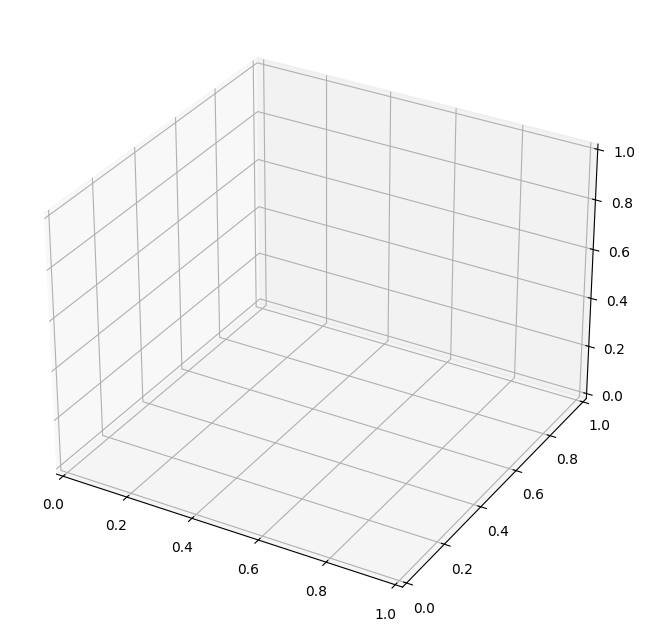

In [ ]:
from IPython.display import HTML

ani_object = animate_adaptive_surface(d=3, sigma=0.45)
html_video = ani_object.to_jshtml()
HTML(html_video)